In [2]:
import pandas as pd

dados = pd.read_csv("../data/dados_maquina.csv")

dados.head()

,temperatura,vibracao,corrente,pressao,horas_operacao,ciclos,falha
0,74.97,4.40,10.65,4.47,1019,27120,0
1,68.62,3.92,11.71,5.31,169,1078,0
2,76.48,3.06,10.42,5.67,4024,36891,1
3,85.23,2.35,11.38,7.51,2186,26473,1
4,67.66,3.70,8.21,6.45,2107,40832,0


In [3]:
X = dados[
    [
        "temperatura",
        "vibracao",
        "corrente",
        "pressao",
        "horas_operacao",
        "ciclos"
    ]
]

y = dados["falha"]

In [4]:
print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
   temperatura  vibracao  corrente  pressao  horas_operacao  ciclos
0        74.97      4.40     10.65     4.47            1019   27120
1        68.62      3.92     11.71     5.31             169    1078
2        76.48      3.06     10.42     5.67            4024   36891
3        85.23      2.35     11.38     7.51            2186   26473
4        67.66      3.70      8.21     6.45            2107   40832

y:
0    0
1    0
2    1
3    1
4    0
Name: falha, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
print("Dados de treinamento:", X_treino.shape)
print("Dados de teste:", X_teste.shape)

Dados de treinamento: (800, 6)
Dados de teste: (200, 6)


In [7]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_treino, y_treino)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [8]:
y_pred = modelo.predict(X_teste)

print(y_pred[:20])

[0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1]


In [9]:
print("Valores reais:")
print(y_teste.values[:20])

print("\nValores previstos:")
print(y_pred[:20])

Valores reais:
[0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1]

Valores previstos:
[0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1]


In [10]:
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_teste, y_pred)

print(f"Acurácia do modelo: {acuracia:.2%}")

Acurácia do modelo: 99.50%


In [11]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("RELATÓRIO DE CLASSIFICAÇÃO")
print(classification_report(
    y_teste,
    y_pred,
    target_names=["Sem Falha", "Com Falha"]
))

RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

   Sem Falha       1.00      0.99      1.00       126
   Com Falha       0.99      1.00      0.99        74

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



In [12]:
matriz = confusion_matrix(y_teste, y_pred)

print("Matriz de Confusão:")
print(matriz)

Matriz de Confusão:
[[125   1]
 [  0  74]]


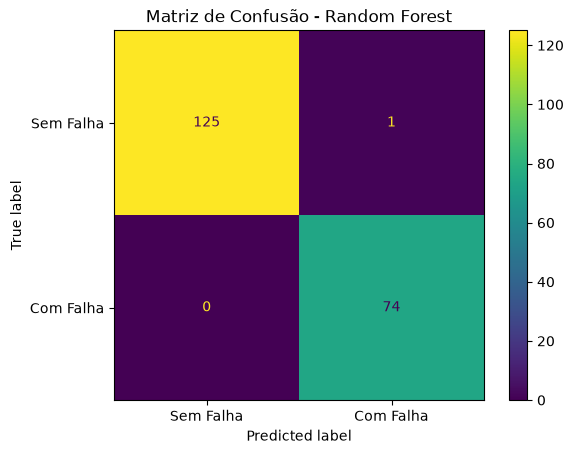

In [13]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Sem Falha", "Com Falha"]
)

disp.plot()
plt.title("Matriz de Confusão - Random Forest")
plt.show()

In [15]:
import pandas as pd

importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias)

horas_operacao    0.511721
vibracao          0.180091
temperatura       0.151984
pressao           0.099906
corrente          0.047046
ciclos            0.009252
dtype: float64


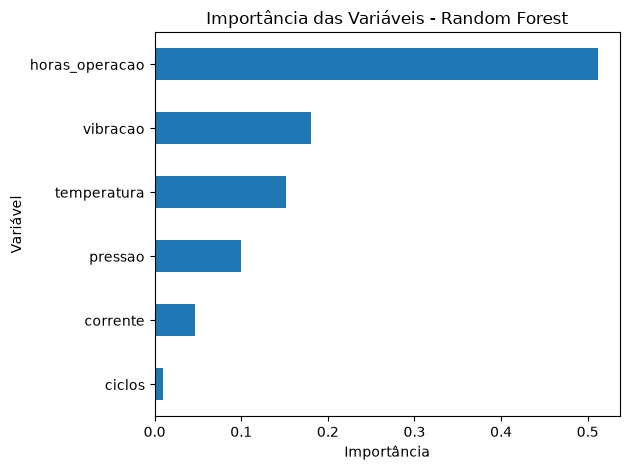

In [16]:
import matplotlib.pyplot as plt

importancias.sort_values().plot(kind="barh")

plt.title("Importância das Variáveis - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

In [17]:
nova_maquina = pd.DataFrame({
    "temperatura": [92.0],
    "vibracao": [5.1],
    "corrente": [17.0],
    "pressao": [7.8],
    "horas_operacao": [4500],
    "ciclos": [40000]
})

nova_maquina

,temperatura,vibracao,corrente,pressao,horas_operacao,ciclos
0,92.0,5.1,17.0,7.8,4500,40000


In [18]:
previsao = modelo.predict(nova_maquina)

print("Previsão:", previsao[0])

if previsao[0] == 1:
    print("⚠️ ALERTA: Máquina com risco de falha!")
else:
    print("✅ Máquina sem indicação de falha.")

Previsão: 1
⚠️ ALERTA: Máquina com risco de falha!


In [19]:
probabilidade = modelo.predict_proba(nova_maquina)

print(f"Probabilidade de não falhar: {probabilidade[0][0]:.2%}")
print(f"Probabilidade de falha: {probabilidade[0][1]:.2%}")

Probabilidade de não falhar: 0.00%
Probabilidade de falha: 100.00%


In [20]:
import joblib
from pathlib import Path

pasta_modelos = Path("../models")
pasta_modelos.mkdir(parents=True, exist_ok=True)

caminho_modelo = pasta_modelos / "modelo_manutencao_preditiva.pkl"

joblib.dump(modelo, caminho_modelo)

print("Modelo salvo com sucesso!")
print(f"Local: {caminho_modelo}")

Modelo salvo com sucesso!
Local: ..\models\modelo_manutencao_preditiva.pkl
